In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [2]:
df = pd.read_csv("mnist_sample_1000.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (1000, 785)


,label,0,1,2,3,4,5,6,7,8,...,774,775,776,777,778,779,780,781,782,783
0,0,25,1,10,0,0,0,7,0,11,...,243,255,254,255,246,255,255,14,0,0
1,7,0,0,11,11,10,27,26,0,6,...,5,16,11,34,0,0,0,11,8,1
2,6,0,13,0,20,51,6,10,0,0,...,236,255,252,255,255,225,255,0,17,17
3,4,0,8,0,9,4,21,1,0,19,...,26,14,0,11,0,0,0,0,15,21
4,4,0,6,0,5,0,0,18,0,36,...,23,0,0,0,4,1,0,0,0,0


In [3]:
y = df["label"].values
X = df.drop("label", axis=1).values

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (1000, 784)
y Shape: (1000,)


Number of pixels: 784


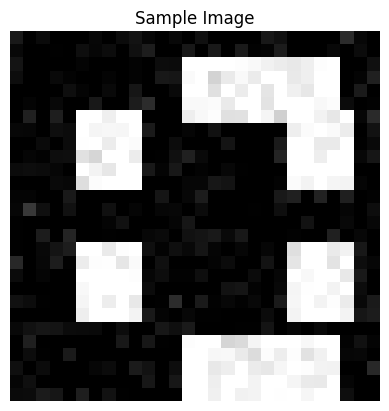

In [15]:
X = df.drop("label", axis=1).values.astype("float32")

print("Number of pixels:", X.shape[1])

X = X.reshape(-1, 28, 28)

plt.imshow(X[0], cmap="gray")
plt.title("Sample Image")
plt.axis("off")
plt.show()

In [5]:
X = X / 255.0

print("Minimum Pixel Value:", X.min())
print("Maximum Pixel Value:", X.max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


In [6]:
y = to_categorical(y, 10)

print("Label Shape:", y.shape)

Label Shape: (1000, 10)


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 28, 28, 1)
Testing Data: (200, 28, 28, 1)


In [8]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       346,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 347,146 (1.32 MB)

 Trainable params: 347,146 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [11]:
history = model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=64,
    verbose=1
)

Epoch 1/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5675 - loss: 1.5269
Epoch 2/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9862 - loss: 0.3854
Epoch 3/3
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 1.0000 - loss: 0.0984


In [12]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", accuracy)
print("Test Loss:", loss)

Test Accuracy: 1.0
Test Loss: 0.05013275146484375


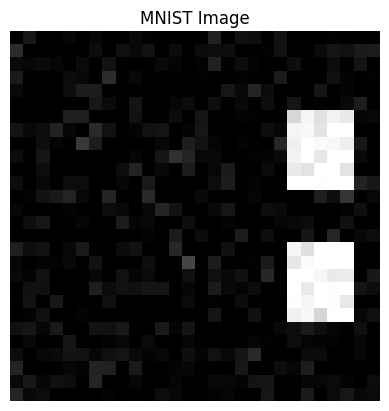

In [13]:
plt.imshow(X_test[0].reshape(28, 28), cmap='gray')
plt.title("MNIST Image")
plt.axis("off")
plt.show()